In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Load your uploaded file
df = pd.read_csv('amazon_reviews.csv')

# 2. Clean data: Remove rows with missing reviews
df = df.dropna(subset=['reviewText'])

# 3. Create Binary Sentiment
# 4.0 and 5.0 stars = 1 (Positive)
# 1.0, 2.0, and 3.0 stars = 0 (Negative)
df['sentiment'] = df['overall'].apply(lambda x: 1 if x >= 4 else 0)

# Extract features and labels
texts = df['reviewText'].astype(str).values
labels = df['sentiment'].values

print(f"Dataset Loaded: {len(df)} reviews found.")
print(f"Sentiment distribution:\n{df['sentiment'].value_counts(normalize=True)}")

Dataset Loaded: 997 reviews found.
Sentiment distribution:
sentiment
1    0.770311
0    0.229689
Name: proportion, dtype: float64


In [2]:
# Hyperparameters
vocab_size = 5000  # Number of unique words to keep
max_length = 150   # Max length of a review
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"
training_split = 0.8

# Split into training and testing sets
split = int(len(texts) * training_split)
train_sentences, test_sentences = texts[:split], texts[split:]
train_labels, test_labels = labels[:split], labels[split:]

# Tokenize words
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sentences)

# Convert to sequences and pad them
train_sequences = tokenizer.texts_to_sequences(train_sentences)
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# Convert labels to numpy arrays
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

print("Preprocessing complete. Data is ready for the GRU.")

Preprocessing complete. Data is ready for the GRU.


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Bidirectional, Dropout, SpatialDropout1D

embedding_dim = 64

model = Sequential([
    # Embedding layer to learn word relationships
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    SpatialDropout1D(0.2),
    # Bidirectional GRU layer
    Bidirectional(GRU(64, return_sequences=True)),
    Bidirectional(GRU(32)),
    # Fully connected layers
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - accuracy: 0.7516 - loss: 0.5999 - val_accuracy: 0.8450 - val_loss: 0.4304
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.7516 - loss: 0.5505 - val_accuracy: 0.8450 - val_loss: 0.4301
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.7516 - loss: 0.5303 - val_accuracy: 0.8450 - val_loss: 0.4248
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.7767 - loss: 0.4689 - val_accuracy: 0.8450 - val_loss: 0.4180
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 207ms/step - accuracy: 0.8758 - loss: 0.3061 - val_accuracy: 0.7800 - val_loss: 0.5043
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 248ms/step - accuracy: 0.9498 - loss: 0.1435 - val_accuracy: 0.8150 - val_loss: 0.7357
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 185ms/step - accuracy: 0.9661 - loss: 0.0814 - val_accuracy: 0.7950 - val_loss: 0.7554
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.9711 - loss: 0.0719 - val_accuracy:

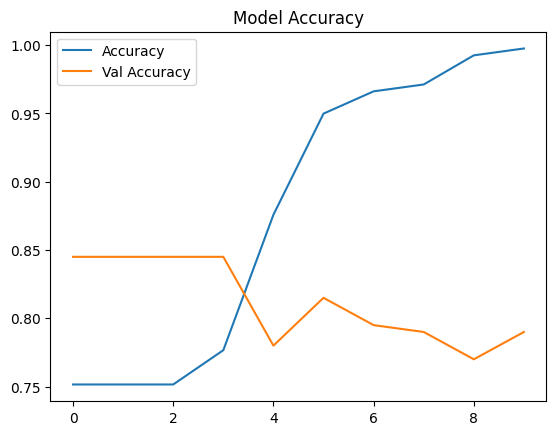

In [4]:
history = model.fit(
    train_padded,
    train_labels,
    epochs=10,
    validation_data=(test_padded, test_labels),
    batch_size=32,
    verbose=1
)

# Plot training results
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

In [5]:
def predict_sentiment(new_reviews):
    seq = tokenizer.texts_to_sequences(new_reviews)
    padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
    predictions = model.predict(padded)

    for i, review in enumerate(new_reviews):
        sentiment = "Positive" if predictions[i] > 0.5 else "Negative"
        confidence = predictions[i][0] if sentiment == "Positive" else 1 - predictions[i][0]
        print(f"Review: {review}")
        print(f"Result: {sentiment} ({confidence*100:.2f}% confidence)\n")

# Example usage:
custom_reviews = [
    "This is an amazing product, I love the features!",
    "Total waste of money. It stopped working after two days.",
    "The delivery was slow, but the device works as expected."
]

predict_sentiment(custom_reviews)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
Review: This is an amazing product, I love the features!
Result: Positive (100.00% confidence)

Review: Total waste of money. It stopped working after two days.
Result: Positive (79.96% confidence)

Review: The delivery was slow, but the device works as expected.
Result: Positive (99.99% confidence)

